<a href="https://colab.research.google.com/github/seorr1/AI_class/blob/main/ai_0311.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 교수님 깃허브 참조 : https://github.com/jskimn/aiservice_lesson

In [ ]:
print("Hello World")

Hello World


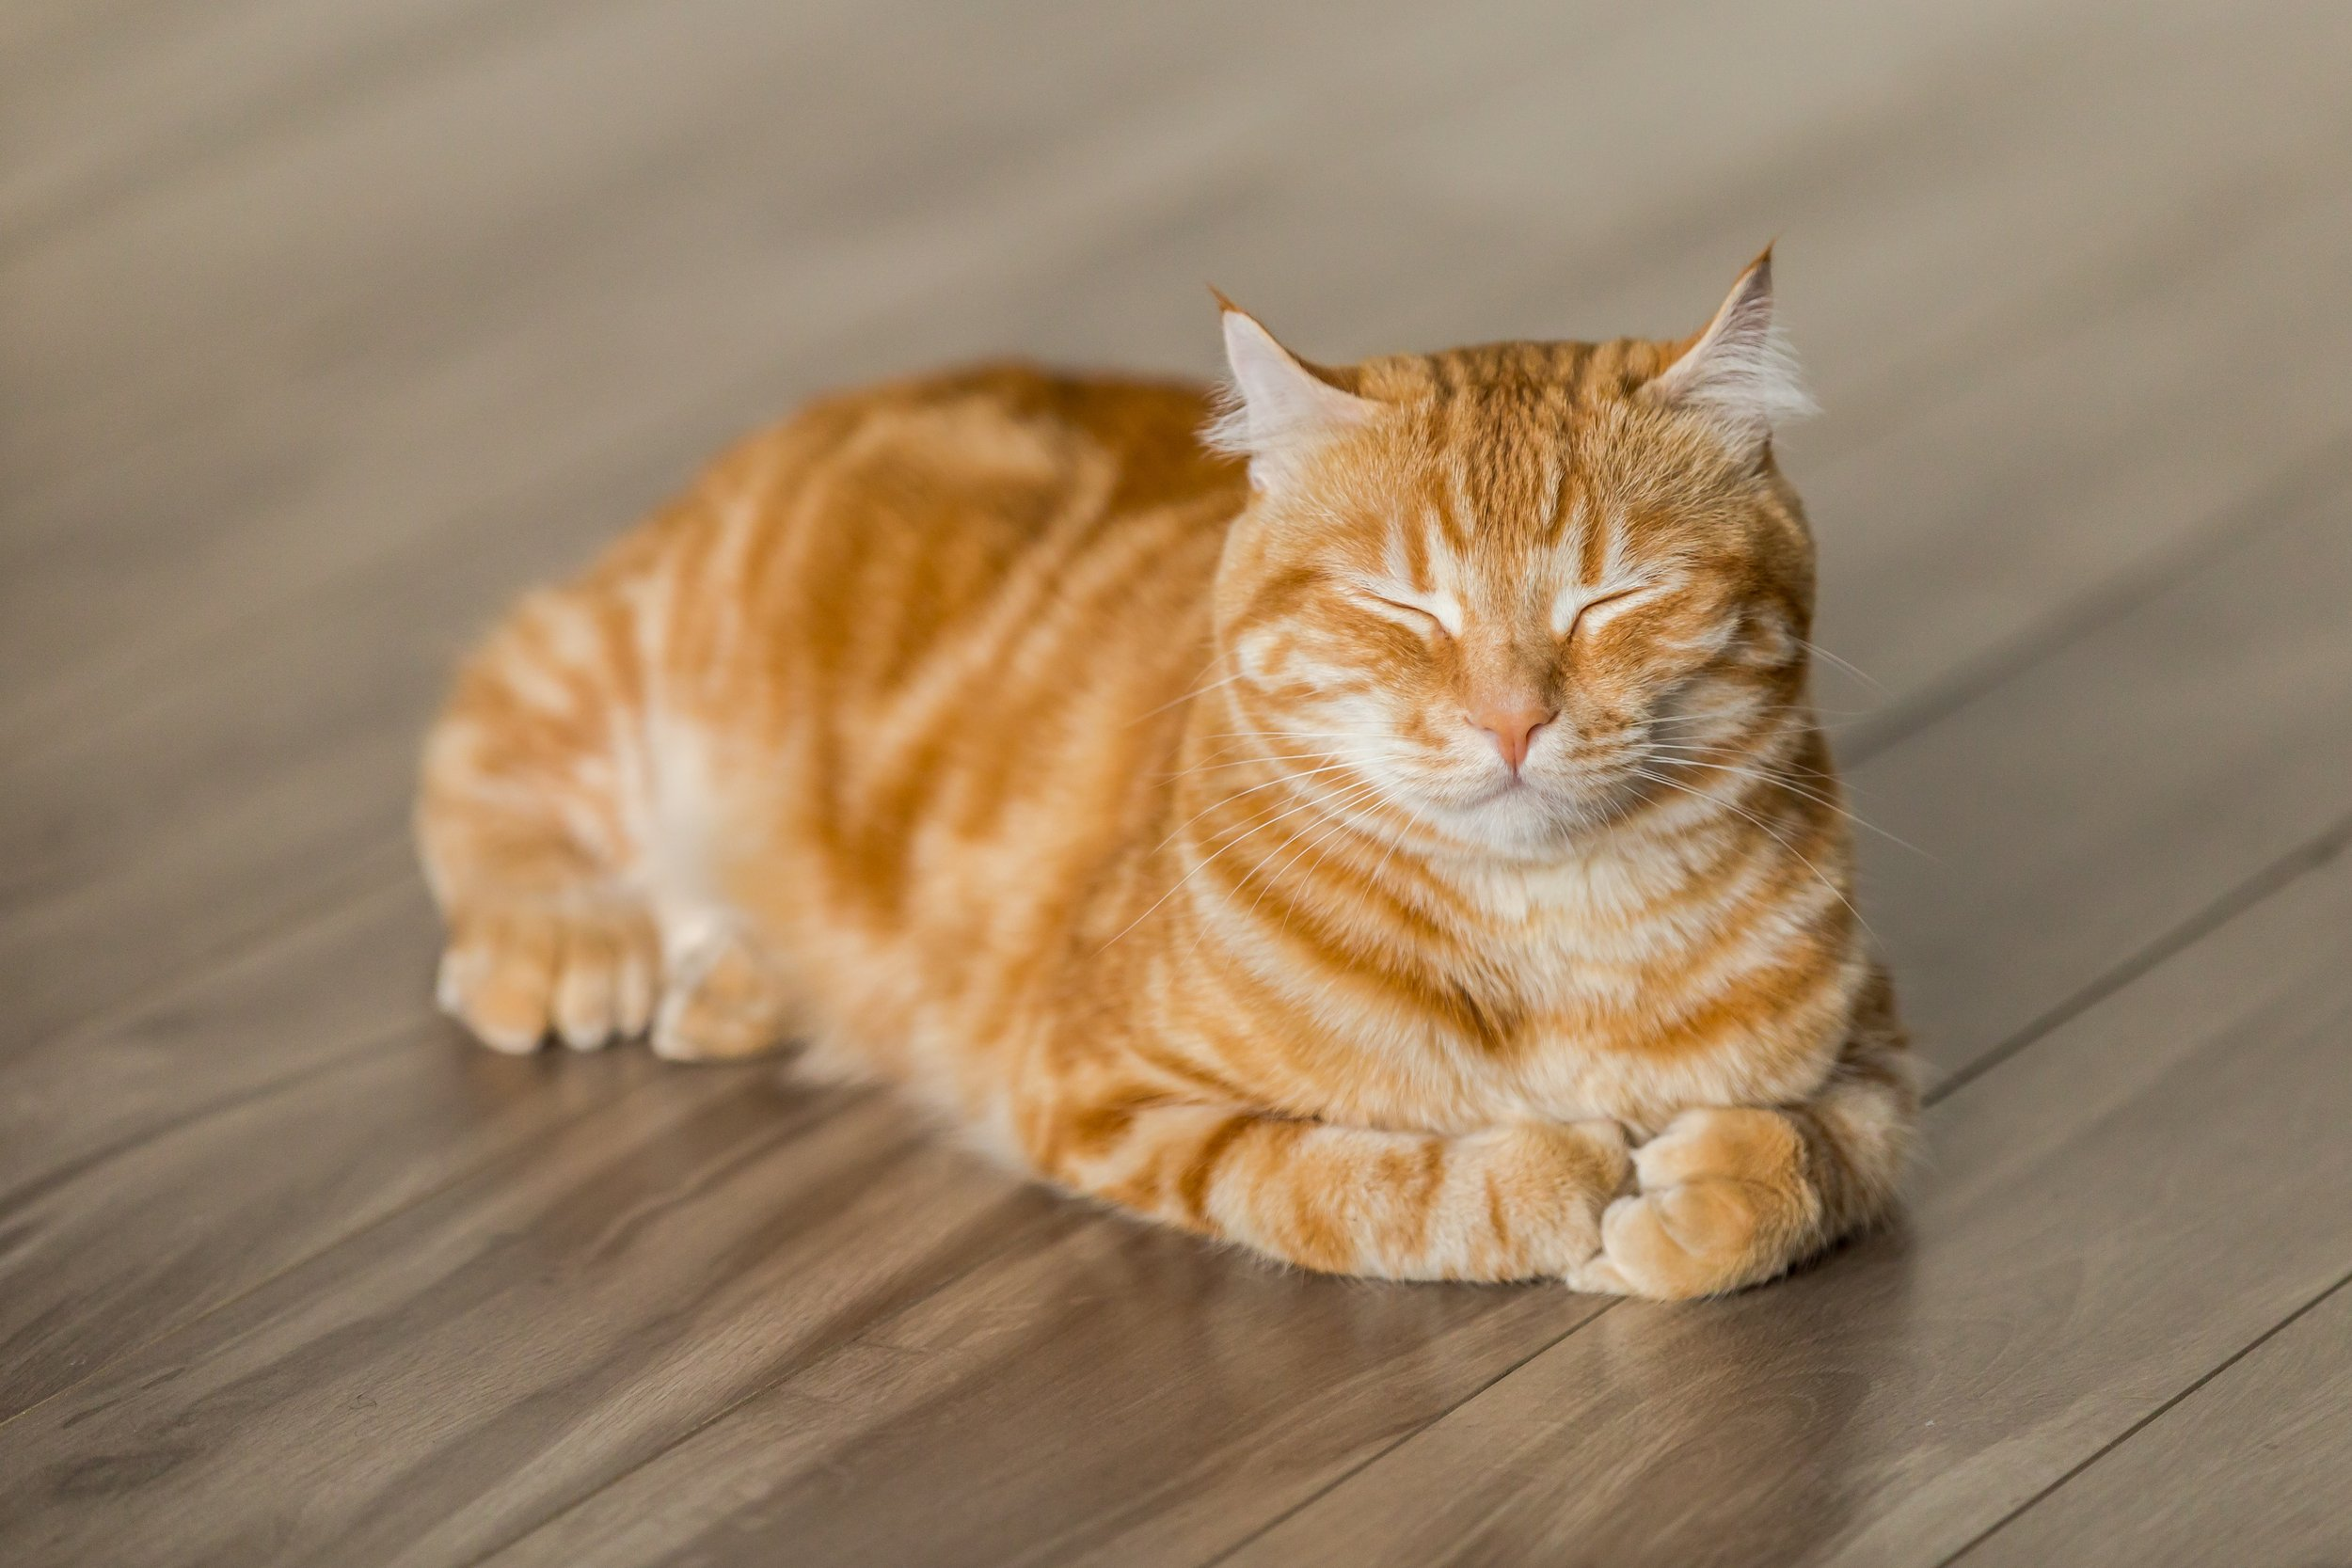

In [ ]:
import cv2
from google.colab.patches import cv2_imshow
img_path = 'cat1.jpg'
img = cv2.imread(img_path)
cv2_imshow(img)

In [ ]:
!pip install matplotlib #안 해도 됨

In [ ]:
import torch
print(torch.__version__)

2.5.1+cu124


In [ ]:
if torch.cuda.is_available():
  device = torch.device('cuda:0')
else:
  device = torch.device('cpu')
print(device)

cpu


In [ ]:
import numpy as np
def AND(x1, x2) :
  x = np.array([x1, x2])
  w = np.array([0.5, 0.5])
  b = -0.7
  tmp = np.sum(w*x) + b
  if tmp > 0 :
    return 1
  else :
    return 0

print(AND(0, 0))
print(AND(0, 1))
print(AND(1, 0))
print(AND(1, 1))

0
0
0
1


In [ ]:
import numpy as np
def OR(x1, x2) :
  x = np.array([x1, x2])
  w = np.array([0.5, 0.5])
  b = -0.2
  tmp = np.sum(w*x) + b
  if tmp > 0 :
    return 1
  else :
    return 0

print(OR(0, 0))
print(OR(0, 1))
print(OR(1, 0))
print(OR(1, 1))

0
1
1
1


In [ ]:
import numpy as np
def NAND(x1, x2) :
  x = np.array([x1, x2])
  w = np.array([-0.5, -0.5])
  b = 0.7
  tmp = np.sum(w * x) + b
  if tmp > 0 :
    return 1
  else :
    return 0

print(NAND(0, 0))
print(NAND(0, 1))
print(NAND(1, 0))
print(NAND(1, 1))

1
1
1
0


In [ ]:
def XOR(x1, x2) :
  s1 = NAND(x1, x2)
  s2 = OR(x1, x2)
  y = AND(s1, s2)
  return y

print(XOR(0, 0))
print(XOR(0, 1))
print(XOR(1, 0))
print(XOR(1, 1))

NameError: name 'OR' is not defined

In [ ]:
def AND(x1, x2):
    return x1 and x2

def OR(x1, x2):
    return x1 or x2

def NAND(x1, x2):
    return not (x1 and x2)

def XOR(x1, x2):
    s1 = NAND(x1, x2)
    s2 = OR(x1, x2)
    y = AND(s1, s2)
    return y

# XOR 함수 테스트
print(XOR(0, 0))  # 0
print(XOR(0, 1))  # 1
print(XOR(1, 0))  # 1
print(XOR(1, 1))  # 0

0
1
1
False


In [ ]:
def XOR(x1, x2) :
  s1 = NAND(x1, x2)
  s2 = OR(x1, x2)
  y = AND(s1, s2)
  return y

print(y)

[0 0 0 1]


In [ ]:
import numpy as np

# 계단 활성화 함수
def step_function(x) :
  return 1 if x >= 0 else 0

# 퍼셉트론 모델
class Perceptron :
  def __init__ (self, input_size, lr = 0.1, epochs = 10) :
    self.weights = np.zeros(input_size)
    self.bias = 0
    self.lr = lr
    self.epochs = epochs

  def predict(self, x) :
    linear_output = np.dot(x, self.weights) + self.bias
    return step_function(linear_output)

  def train(self, X, y) :
    for epoch in range(self.epochs) :
      for i in range(len(X)) :
        y_pred = self.predict(X[i])
        error = y[i] - y_pred
        self.weights += self.lr * error * X[i]
        self.bias += self.lr * error
      print(f"Epoch {epoch+1} ; Weights = {self.weights}, Bias = {self.bias}, Error = {error}")

In [ ]:
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([0, 0, 0, 1])

In [ ]:
perceptron = Perceptron(input_size = 2, lr = 0.1, epochs = 10)
perceptron.train(X, y)

Epoch 1 ; Weights = [0.1 0.1], Bias = 0.0, Error = 1
Epoch 2 ; Weights = [0.2 0.1], Bias = -0.1, Error = 1
Epoch 3 ; Weights = [0.2 0.1], Bias = -0.20000000000000004, Error = 1
Epoch 4 ; Weights = [0.2 0.1], Bias = -0.20000000000000004, Error = 0
Epoch 5 ; Weights = [0.2 0.1], Bias = -0.20000000000000004, Error = 0
Epoch 6 ; Weights = [0.2 0.1], Bias = -0.20000000000000004, Error = 0
Epoch 7 ; Weights = [0.2 0.1], Bias = -0.20000000000000004, Error = 0
Epoch 8 ; Weights = [0.2 0.1], Bias = -0.20000000000000004, Error = 0
Epoch 9 ; Weights = [0.2 0.1], Bias = -0.20000000000000004, Error = 0
Epoch 10 ; Weights = [0.2 0.1], Bias = -0.20000000000000004, Error = 0


In [ ]:
print("\n{학습 결과}")
print(f"Weight : {perceptron.weights}, Bias : {perceptron.bias}")

# 결과 확인
print("\n{게이트 테스트}")
for inputs in X :
  print(f"입력 : {inputs}, 출력 : {perceptron.predict(inputs)}")


{학습 결과}
Weight : [0.2 0.1], Bias : -0.20000000000000004

{게이트 테스트}
입력 : [0 0], 출력 : 0
입력 : [0 1], 출력 : 0
입력 : [1 0], 출력 : 0
입력 : [1 1], 출력 : 1


In [ ]:
perceptron = Perceptron(input_size = 2, lr = 0.1, epochs = 100)
perceptron.train(X, y)

print("\n{학습 결과}")
print(f"Weight : {perceptron.weights}, Bias : {perceptron.bias}")

# 결과 확인
print("\n{게이트 테스트}")
for inputs in X :
  print(f"입력 : {inputs}, 출력 : {perceptron.predict(inputs)}")

Epoch 1 ; Weights = [0.1 0.1], Bias = 0.0, Error = 1
Epoch 2 ; Weights = [0.2 0.1], Bias = -0.1, Error = 1
Epoch 3 ; Weights = [0.2 0.1], Bias = -0.20000000000000004, Error = 1
Epoch 4 ; Weights = [0.2 0.1], Bias = -0.20000000000000004, Error = 0
Epoch 5 ; Weights = [0.2 0.1], Bias = -0.20000000000000004, Error = 0
Epoch 6 ; Weights = [0.2 0.1], Bias = -0.20000000000000004, Error = 0
Epoch 7 ; Weights = [0.2 0.1], Bias = -0.20000000000000004, Error = 0
Epoch 8 ; Weights = [0.2 0.1], Bias = -0.20000000000000004, Error = 0
Epoch 9 ; Weights = [0.2 0.1], Bias = -0.20000000000000004, Error = 0
Epoch 10 ; Weights = [0.2 0.1], Bias = -0.20000000000000004, Error = 0
Epoch 11 ; Weights = [0.2 0.1], Bias = -0.20000000000000004, Error = 0
Epoch 12 ; Weights = [0.2 0.1], Bias = -0.20000000000000004, Error = 0
Epoch 13 ; Weights = [0.2 0.1], Bias = -0.20000000000000004, Error = 0
Epoch 14 ; Weights = [0.2 0.1], Bias = -0.20000000000000004, Error = 0
Epoch 15 ; Weights = [0.2 0.1], Bias = -0.200000

In [ ]:
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
# NAND 정답
y_nand = np.array([1, 1, 1, 0])
# AND 정답
y_and = np.array([0, 0, 0, 1])
# OR 정답
y_or = np.array([0, 1, 1, 1])

In [ ]:
# NAND
perceptron_nand = Perceptron(input_size = 2, lr = 0.1, epochs = 10)
perceptron_nand.train(X, y_nand)
weights_nand = perceptron_nand.weights
bias_nand = perceptron_nand.bias

Epoch 1 ; Weights = [-0.1 -0.1], Bias = -0.1, Error = -1
Epoch 2 ; Weights = [-0.2 -0.1], Bias = 0.0, Error = -1
Epoch 3 ; Weights = [-0.2 -0.1], Bias = 0.1, Error = -1
Epoch 4 ; Weights = [-0.2 -0.2], Bias = 0.1, Error = -1
Epoch 5 ; Weights = [-0.2 -0.1], Bias = 0.2, Error = 0
Epoch 6 ; Weights = [-0.2 -0.1], Bias = 0.2, Error = 0
Epoch 7 ; Weights = [-0.2 -0.1], Bias = 0.2, Error = 0
Epoch 8 ; Weights = [-0.2 -0.1], Bias = 0.2, Error = 0
Epoch 9 ; Weights = [-0.2 -0.1], Bias = 0.2, Error = 0
Epoch 10 ; Weights = [-0.2 -0.1], Bias = 0.2, Error = 0


In [ ]:
# AND
perceptron_and = Perceptron(input_size = 2, lr = 0.1, epochs = 10)
perceptron_and.train(X, y_and)
weights_and = perceptron_and.weights
bias_and = perceptron_and.bias

Epoch 1 ; Weights = [0.1 0.1], Bias = 0.0, Error = 1
Epoch 2 ; Weights = [0.2 0.1], Bias = -0.1, Error = 1
Epoch 3 ; Weights = [0.2 0.1], Bias = -0.20000000000000004, Error = 1
Epoch 4 ; Weights = [0.2 0.1], Bias = -0.20000000000000004, Error = 0
Epoch 5 ; Weights = [0.2 0.1], Bias = -0.20000000000000004, Error = 0
Epoch 6 ; Weights = [0.2 0.1], Bias = -0.20000000000000004, Error = 0
Epoch 7 ; Weights = [0.2 0.1], Bias = -0.20000000000000004, Error = 0
Epoch 8 ; Weights = [0.2 0.1], Bias = -0.20000000000000004, Error = 0
Epoch 9 ; Weights = [0.2 0.1], Bias = -0.20000000000000004, Error = 0
Epoch 10 ; Weights = [0.2 0.1], Bias = -0.20000000000000004, Error = 0


In [ ]:
# OR
perceptron_or = Perceptron(input_size = 2, lr = 0.1, epochs = 10)
perceptron_or.train(X, y_or)
weights_or = perceptron_or.weights
bias_or = perceptron_or.bias

Epoch 1 ; Weights = [0.  0.1], Bias = 0.0, Error = 0
Epoch 2 ; Weights = [0.1 0.1], Bias = 0.0, Error = 0
Epoch 3 ; Weights = [0.1 0.1], Bias = -0.1, Error = 0
Epoch 4 ; Weights = [0.1 0.1], Bias = -0.1, Error = 0
Epoch 5 ; Weights = [0.1 0.1], Bias = -0.1, Error = 0
Epoch 6 ; Weights = [0.1 0.1], Bias = -0.1, Error = 0
Epoch 7 ; Weights = [0.1 0.1], Bias = -0.1, Error = 0
Epoch 8 ; Weights = [0.1 0.1], Bias = -0.1, Error = 0
Epoch 9 ; Weights = [0.1 0.1], Bias = -0.1, Error = 0
Epoch 10 ; Weights = [0.1 0.1], Bias = -0.1, Error = 0


In [ ]:
# XOR
def XOR(x) :
  nand_output = step_function(np.dot(x, weights_nand) + bias_nand)
  or_output = step_function(np.dot(x, weights_or) + bias_or)
  and_input = np.array([nand_output, or_output])
  #print(f"입력 : {x}, nand_output : {nand_output}, and_output : {and_output}, or_input : {and_input}")
  xor_output = step_function(np.dot(and_input, weights_and) + bias_and)
  return xor_output
for inputs in X :
  #XOR(inputs)
  print(f"입력 : {inputs}, 출력 : {XOR(inputs)}")

  # XOR의 정답 : 값이 같을 때는 0, 다를 때는 1

입력 : [0 0], 출력 : 0
입력 : [0 1], 출력 : 1
입력 : [1 0], 출력 : 1
입력 : [1 1], 출력 : 0


In [ ]:
class MulLayer :
  def __init__(self) :
    self.x = None
    self.y = None

  # 곱셈  z = x * y
  def forward(self, x, y) :
    self.x = x
    self.y = y
    out = x * y
    return out

  def backward(self, dout) :
    dx = dout * self.y # x와 y를 바꾼다.
    dy = dout * self.x
    return dx, dy

In [ ]:
class MulTaxLayer:
    def __init__(self):
        self.x = None
        self.y = None

    def forward(self, x):
        self.x = x
        # 예시로 self.y를 x에 어떤 값을 곱하는 방식으로 설정
        self.y = x * 2  # 예시로 2배를 곱하는 계산
        return self.y

    def backward(self, dout):
        if self.y is None:
            raise ValueError("self.y는 None입니다. forward를 먼저 호출해야 합니다.")
        if self.x is None:
            raise ValueError("self.x는 None입니다. forward를 먼저 호출해야 합니다.")

        dx = dout * self.y  # self.y는 None일 수 없게 보장됨
        dy = dout * self.x  # self.x는 None일 수 없게 보장됨
        return dx, dy

# 예시로 사용
mul_tax_layer = MulTaxLayer()

# forward 호출 후 backward를 호출해야 정상적으로 작동
mul_tax_layer.forward(3)  # 예시로 3을 넣고 forward 실행
dprice = 1
dapple_price, dtax = mul_tax_layer.backward(dprice)  # backward 호출
print(dapple_price, dtax)

6 3


In [ ]:
class MulAppleLayer:
    def __init__(self):
        self.x = None
        self.y = None

    def forward(self, x):
        self.x = x
        # self.y가 x에 따라 계산되는 값으로 설정되어야 함
        self.y = x * 3  # 예시로 3배를 곱하는 계산
        return self.y

    def backward(self, dout):
        if self.y is None:
            raise ValueError("self.y는 None입니다. forward를 먼저 호출해야 합니다.")
        if self.x is None:
            raise ValueError("self.x는 None입니다. forward를 먼저 호출해야 합니다.")

        dx = dout * self.y  # self.y가 None이 아닌지 확인
        dy = dout * self.x  # self.x가 None이 아닌지 확인
        return dx, dy

# 예시로 사용
mul_apple_layer = MulAppleLayer()

# forward 호출 후 backward를 호출해야 정상적으로 작동
mul_apple_layer.forward(5)  # 예시로 5를 넣고 forward 실행
dprice = 1
dapple_price, dtax = mul_tax_layer.backward(dprice)  # mul_tax_layer backward 실행
dapple, dapple_num = mul_apple_layer.backward(dapple_price)  # mul_apple_layer backward 실행
print(dapple, dapple_num, dtax)


90 30 3


In [ ]:
apple = 100
apple_num = 2
tax = 1.1

mul_apple_layer = MulLayer()
mul_tax_layer = MulLayer()

In [ ]:
apple_price = mul_apple_layer.forward(apple, apple_num)
price = mul_tax_layer.forward(apple_price, tax)
print(price)

220.00000000000003


In [ ]:
dprice = 1
dapple_price, dtax = mul_tax_layer.backward(dprice)
dapple, dapple_num = mul_apple_layer.backward(dapple_price)
print(dapple, apple_num, dtax)

90 2 3


In [ ]:
import sys, os
if not os.path.exists("dataset/mnist.py"):
  !wget -P dataset https://raw.githubusercontent.com/jskimn/aiservice_lesson/main/NNBasic/005_minist/dataset/mnist.py

if not os.path.exists("dataset/train-images-idx3-ubyte.gz"):
  !wget -P dataset https://raw.githubusercontent.com/jskimn/aiservice_lesson/main/NNBasic/005_minist/dataset/train-images-idx3-ubyte.gz

if not os.path.exists("dataset/train-labels-idx1-ubyte.gz"):
  !wget -P dataset https://raw.githubusercontent.com/jskimn/aiservice_lesson/main/NNBasic/005_minist/dataset/train-labels-idx1-ubyte.gz

if not os.path.exists("dataset/t10k-images-idx3-ubyte.gz"):
  !wget -P dataset https://raw.githubusercontent.com/jskimn/aiservice_lesson/main/NNBasic/005_minist/dataset/t10k-images-idx3-ubyte.gz

if not os.path.exists("dataset/t10k-labels-idx1-ubyte.gz"):
  !wget -P dataset https://raw.githubusercontent.com/jskimn/aiservice_lesson/main/NNBasic/005_minist/dataset/t10k-labels-idx1-ubyte.gz

#sample weight 추가
if not os.path.exists("dataset/sample_weight.pkl"):
  !wget -P dataset https://raw.githubusercontent.com/jskimn/aiservice_lesson/main/NNBasic/005_minist/dataset/sample_weight.pkl

#확인
!realpath dataset/mnist.py
!ls dataset

--2025-03-25 10:41:28--  https://raw.githubusercontent.com/jskimn/aiservice_lesson/main/NNBasic/005_minist/dataset/mnist.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3655 (3.6K) [text/plain]
Saving to: ‘dataset/mnist.py’

mnist.py            100%[===================>]   3.57K  --.-KB/s    in 0s      

2025-03-25 10:41:28 (38.7 MB/s) - ‘dataset/mnist.py’ saved [3655/3655]

--2025-03-25 10:41:28--  https://raw.githubusercontent.com/jskimn/aiservice_lesson/main/NNBasic/005_minist/dataset/train-images-idx3-ubyte.gz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, a

In [ ]:
#sys.path.append(os.pardir)
from dataset.mnist import load_mnist

(x_train, t_train), (x_test, t_test) = load_mnist(flatten=True, normalize=False)

# 각 데이터 shape 출력
print(x_train.shape)
print(t_train.shape)
print(x_test.shape)
print(t_test.shape)

Converting train-images-idx3-ubyte.gz to NumPy Array ...
Done
Converting train-labels-idx1-ubyte.gz to NumPy Array ...
Done
Converting t10k-images-idx3-ubyte.gz to NumPy Array ...
Done
Converting t10k-labels-idx1-ubyte.gz to NumPy Array ...
Done
Creating pickle file ...
Done!
(60000, 784)
(60000,)
(10000, 784)
(10000,)


(784,)
5


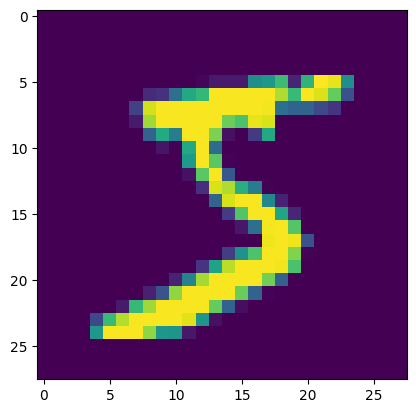

In [ ]:
%matplotlib inline
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

def img_show(img):
    pil_img = Image.fromarray(np.uint8(img))
    #pil_img.show()
    plt.imshow(np.array(pil_img))

img = x_train[0]
print(img.shape)
label = t_train[0]
img = img.reshape(28, 28)
img_show(img)

print(label)

In [ ]:
import sys, os
if not os.path.exists("dataset/mnist.py"):
   !wget -P dataset https://raw.githubusercontent.com/jskimn/aiservice_lesson/main/NNBasic/005_minist/dataset/mnist.py

if not os.path.exists("common/functions.py"):
  !wget -P common https://raw.githubusercontent.com/jskimn/aiservice_lesson/main/NNBasic/005_minist/common/functions.py

if not os.path.exists("dataset/train-images-idx3-ubyte.gz"):
  !wget -P dataset https://raw.githubusercontent.com/jskimn/aiservice_lesson/main/NNBasic/005_minist/dataset/train-images-idx3-ubyte.gz

if not os.path.exists("dataset/train-labels-idx1-ubyte.gz"):
  !wget -P dataset https://raw.githubusercontent.com/jskimn/aiservice_lesson/main/NNBasic/005_minist/dataset/train-labels-idx1-ubyte.gz

if not os.path.exists("dataset/t10k-images-idx3-ubyte.gz"):
  !wget -P dataset https://raw.githubusercontent.com/jskimn/aiservice_lesson/main/NNBasic/005_minist/dataset/t10k-images-idx3-ubyte.gz

if not os.path.exists("dataset/t10k-labels-idx1-ubyte.gz"):
  !wget -P dataset https://raw.githubusercontent.com/jskimn/aiservice_lesson/main/NNBasic/005_minist/dataset/t10k-labels-idx1-ubyte.gz

  #sample weight 추가
if not os.path.exists("dataset/sample_weight.pkl"):
  !wget -P dataset https://raw.githubusercontent.com/jskimn/aiservice_lesson/main/NNBasic/005_minist/dataset/sample_weight.pkl

  #확인
!realpath dataset/mnist.py
!ls dataset

--2025-03-25 10:57:44--  https://raw.githubusercontent.com/jskimn/aiservice_lesson/main/NNBasic/005_minist/common/functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1075 (1.0K) [text/plain]
Saving to: ‘common/functions.py’

functions.py        100%[===================>]   1.05K  --.-KB/s    in 0s      

2025-03-25 10:57:44 (75.2 MB/s) - ‘common/functions.py’ saved [1075/1075]

/content/dataset/mnist.py
mnist.pkl  __pycache__	      t10k-images-idx3-ubyte.gz  train-images-idx3-ubyte.gz
mnist.py   sample_weight.pkl  t10k-labels-idx1-ubyte.gz  train-labels-idx1-ubyte.gz


In [ ]:
from dataset.mnist import load_mnist
from common.functions import sigmoid, softmax
import numpy as np
import pickle

def get_data():
    (x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, flatten=True, one_hot_label=False)
    return x_test, t_test

def init_network():
    with open("dataset/sample_weight.pkl", 'rb') as f:
        network = pickle.load(f)
    return network

def predict(network, x):
    W1, W2, W3 = network['W1'], network['W2'], network['W3']
    b1, b2, b3 = network['b1'], network['b2'], network['b3']

    a1 = np.dot(x, W1) + b1
    z1 = sigmoid(a1)
    a2 = np.dot(z1, W2) + b2
    z2 = sigmoid(a2)
    a3 = np.dot(z2, W3) + b3
    y = softmax(a3)

    return y

In [ ]:
x, t = get_data()
network = init_network()
accuracy_cnt = 0
for i in range(len(x)):
    y = predict(network, x[i])
    p= np.argmax(y) # 확률이 가장 높은 원소의 인덱스를 얻는다.
    if p == t[i]:
        accuracy_cnt += 1

print("Accuracy:" + str(float(accuracy_cnt) / len(x)))

Accuracy:0.9352


In [ ]:
import sys, os
if not os.path.exists("dataset/mnist.py"):
  !wget -P dataset https://raw.githubusercontent.com/jskimn/aiservice_lesson/main/NNBasic/005_minist/dataset/mnist.py

if not os.path.exists("dataset/train-images-idx3-ubyte.gz"):
  !wget -P dataset https://raw.githubusercontent.com/jskimn/aiservice_lesson/main/NNBasic/005_minist/dataset/train-images-idx3-ubyte.gz

if not os.path.exists("dataset/train-labels-idx1-ubyte.gz"):
  !wget -P dataset https://raw.githubusercontent.com/jskimn/aiservice_lesson/main/NNBasic/005_minist/dataset/train-labels-idx1-ubyte.gz

if not os.path.exists("dataset/t10k-images-idx3-ubyte.gz"):
  !wget -P dataset https://raw.githubusercontent.com/jskimn/aiservice_lesson/main/NNBasic/005_minist/dataset/t10k-images-idx3-ubyte.gz

if not os.path.exists("dataset/t10k-labels-idx1-ubyte.gz"):
  !wget -P dataset https://raw.githubusercontent.com/jskimn/aiservice_lesson/main/NNBasic/005_minist/dataset/t10k-labels-idx1-ubyte.gz

  #common 파일 다운르도
if not os.path.exists("common/functions.py"):
  !wget -P common https://raw.githubusercontent.com/jskimn/aiservice_lesson/main/NNBasic/005_minist/common/functions.py

if not os.path.exists("common/gradient.py"):
  !wget -P common https://raw.githubusercontent.com/jskimn/aiservice_lesson/main/NNBasic/005_minist/common/gradient.py

  #TwoLayerNet.py 다운로드
if not os.path.exists("TwoLayerNet.py"):
  !wget https://raw.githubusercontent.com/jskimn/aiservice_lesson/main/NNBasic/005_minist/TwoLayerNet.py


  #확인
!realpath dataset/mnist.py
!ls dataset

--2025-03-25 10:59:09--  https://raw.githubusercontent.com/jskimn/aiservice_lesson/main/NNBasic/005_minist/common/gradient.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1204 (1.2K) [text/plain]
Saving to: ‘common/gradient.py’

gradient.py         100%[===================>]   1.18K  --.-KB/s    in 0s      

2025-03-25 10:59:09 (81.9 MB/s) - ‘common/gradient.py’ saved [1204/1204]

--2025-03-25 10:59:09--  https://raw.githubusercontent.com/jskimn/aiservice_lesson/main/NNBasic/005_minist/TwoLayerNet.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting respon

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from TwoLayerNet import TwoLayerNet

# 데이터 읽기
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)


# 하이퍼파라미터
iters_num = 10000  # 반복 횟수를 적절히 설정한다.
train_size = x_train.shape[0]
batch_size = 100   # 미니배치 크기
learning_rate = 0.1

#losss 및 정확도 변수
train_loss_list = []
train_acc_list = []
test_acc_list = []

# 1에폭당 반복 수
iter_per_epoch = max(train_size / batch_size, 1)

network = TwoLayerNet(input_size=784, hidden_size=50, output_size=10)

for i in range(iters_num):
    # 미니배치 획득
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    # 기울기 계산
    #grad = network.numerical_gradient(x_batch, t_batch)
    grad = network.gradient(x_batch, t_batch)

    # 매개변수 갱신
    for key in ('W1', 'b1', 'W2', 'b2'):
        network.params[key] -= learning_rate * grad[key]

    # 학습 경과 기록
    loss = network.loss(x_batch, t_batch)
    train_loss_list.append(loss)

    # 1에폭당 정확도 계산
    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)
        print("train acc, test acc | " + str(train_acc) + ", " + str(test_acc))

train acc, test acc | 0.11236666666666667, 0.1135
train acc, test acc | 0.7675166666666666, 0.7771
train acc, test acc | 0.8738, 0.8784
train acc, test acc | 0.8984833333333333, 0.9007
train acc, test acc | 0.9071666666666667, 0.9095
train acc, test acc | 0.9132666666666667, 0.9145
train acc, test acc | 0.92035, 0.9207
train acc, test acc | 0.9243166666666667, 0.9254
train acc, test acc | 0.9273166666666667, 0.9289
train acc, test acc | 0.9305833333333333, 0.9306
train acc, test acc | 0.9334666666666667, 0.9332
train acc, test acc | 0.9361666666666667, 0.9367
train acc, test acc | 0.93835, 0.9386
train acc, test acc | 0.9411, 0.9389
train acc, test acc | 0.9432666666666667, 0.9421
train acc, test acc | 0.9453833333333334, 0.9436
train acc, test acc | 0.9475, 0.9452


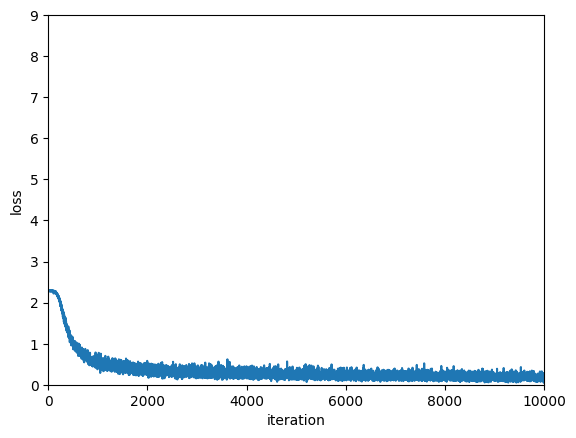

In [ ]:
# 그래프 그리기
x = np.arange(len(train_loss_list))
plt.plot(x, train_loss_list)
plt.xlabel("iteration")
plt.ylabel("loss")
plt.ylim(0, 9)
plt.xlim(0, 10000)
plt.show()

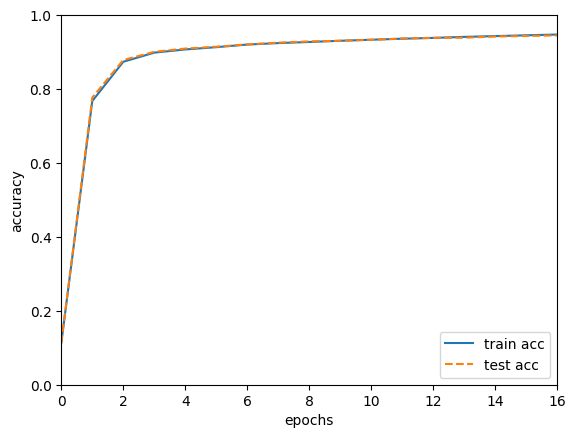

In [ ]:
x = np.arange(len(train_acc_list))
plt.plot(x, train_acc_list, label='train acc')
plt.plot(x, test_acc_list, label='test acc', linestyle='--')
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.xlim(0, 16)
plt.legend(loc='lower right')
plt.show()

In [ ]:
# TwoLayerNet 클래스 정의
class TwoLayerNet:

    def __init__(self, input_size, hidden_size, output_size, weight_init_std=0.01):
        # 가중치 초기화
        self.params = {}
        self.params['W1'] = weight_init_std * np.random.randn(input_size, hidden_size)
        self.params['b1'] = np.zeros(hidden_size)
        self.params['W2'] = weight_init_std * np.random.randn(hidden_size, output_size)
        self.params['b2'] = np.zeros(output_size)

In [ ]:
# 예측 함수 정의
def predict(self, x):
        W1, W2 = self.params['W1'], self.params['W2']
        b1, b2 = self.params['b1'], self.params['b2']

        a1 = np.dot(x, W1) + b1
        z1 = sigmoid(a1)
        a2 = np.dot(z1, W2) + b2
        y = softmax(a2)

        return y

In [ ]:
# Loss 함수
# x : 입력 데이터, t : 정답 레이블
def loss(self, x, t):
    y = self.predict(x)

    return cross_entropy_error(y, t)

In [ ]:
# 정확도 측정 함수
def accuracy(self, x, t):
        y = self.predict(x)
        y = np.argmax(y, axis=1)
        t = np.argmax(t, axis=1)

        accuracy = np.sum(y == t) / float(x.shape[0])
        return accuracy

In [ ]:
# 가중치 매개변수의 기울기
# x : 입력 데이터, t : 정답 레이블
def numerical_gradient(self, x, t):
    loss_W = lambda W: self.loss(x, t)

    grads = {}
    grads['W1'] = numerical_gradient(loss_W, self.params['W1'])
    grads['b1'] = numerical_gradient(loss_W, self.params['b1'])
    grads['W2'] = numerical_gradient(loss_W, self.params['W2'])
    grads['b2'] = numerical_gradient(loss_W, self.params['b2'])

    return grads

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [ ]:
# Device 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# 전처리
transform = transforms.Compose([
    transforms.ToTensor(),           # PyTorch 텐서 변환
    transforms.Normalize((0.5,), (0.5,))  # 정규화 (-1 ~ 1)
])

In [ ]:
# MNIST 데이터셋 로드
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=100, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=100, shuffle=False)

In [ ]:
# 신경망 모델 클래스 정의
class TwoLayerNet(nn.Module):
    def __init__(self):
        super(TwoLayerNet, self).__init__()
        self.fc1 = nn.Linear(28*28, 50, bias=False)   # 편향 제거 (Hebbian 방식)
        self.fc2 = nn.Linear(50, 10, bias=False)     # 은닉층 → 출력층 (10 뉴런)

    def forward(self, x):
        x = x.view(-1, 28*28)  # 2D 이미지 -> 1D 벡터 변환
        x = torch.relu(self.fc1(x))  # 은닉층
        x = self.fc2(x)  # Softmax는 CrossEntropyLoss에서 자동 적용됨
        return x

In [ ]:
# 모델, 손실함수, 최적화 함수 생성
model = TwoLayerNet().to(device)
criterion = nn.CrossEntropyLoss() #손실함수: 교차 엔트로피 함수
learning_rate = 0.01  # 학습률

In [ ]:
# 학습
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms

# 1. 모델 학습
num_epochs = 16
train_losses, test_accuracies = [], []

for epoch in range(num_epochs):
    running_loss = 0.0

    # 모델 학습
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # 순전파
        images = images.view(images.size(0), -1)  # [batch_size, 28*28]
        labels_one_hot = torch.nn.functional.one_hot(labels, num_classes=10).float()  # (batch_size, 10)

        # 1. fc1 (입력 → 숨은층) 가중치 업데이트
        hidden_output = torch.relu(model.fc1(images))  # Hidden Layer Output (batch_size, 50)
        for name, param in model.named_parameters():
            if name == "fc1.weight":  # Hidden Layer 가중치 업데이트
                param.data = param.data + learning_rate * torch.matmul(hidden_output.T, images)  # (50, 784)

        # 2. fc2 (숨은층 → 출력) 가중치 업데이트
        for name, param in model.named_parameters():
            if name == "fc2.weight":  # Output Layer 가중치 업데이트
                param.data = param.data + learning_rate * torch.matmul(labels_one_hot.T, hidden_output)  # (10, 50)


    # 훈련 손실 기록
    train_losses.append(running_loss / len(train_loader))

    # 테스트 정확도 계산
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    test_acc = correct / total
    test_accuracies.append(test_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}], Test Accuracy: {test_acc:.4f}")

Epoch [1/16], Test Accuracy: 0.0980
Epoch [2/16], Test Accuracy: 0.0980
Epoch [3/16], Test Accuracy: 0.0980
Epoch [4/16], Test Accuracy: 0.0980
Epoch [5/16], Test Accuracy: 0.0980
Epoch [6/16], Test Accuracy: 0.0980
Epoch [7/16], Test Accuracy: 0.0980
Epoch [8/16], Test Accuracy: 0.0980
Epoch [9/16], Test Accuracy: 0.0980
Epoch [10/16], Test Accuracy: 0.0980
Epoch [11/16], Test Accuracy: 0.0980
Epoch [12/16], Test Accuracy: 0.0980
Epoch [13/16], Test Accuracy: 0.0980
Epoch [14/16], Test Accuracy: 0.0980
Epoch [15/16], Test Accuracy: 0.0980
Epoch [16/16], Test Accuracy: 0.0980


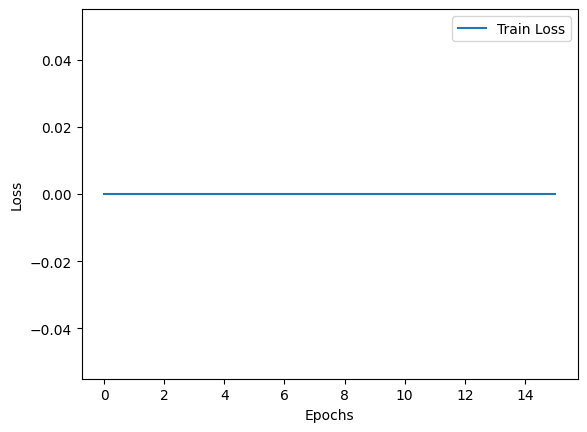

In [ ]:
# Loss 그래프 시각화
plt.plot(train_losses, label="Train Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

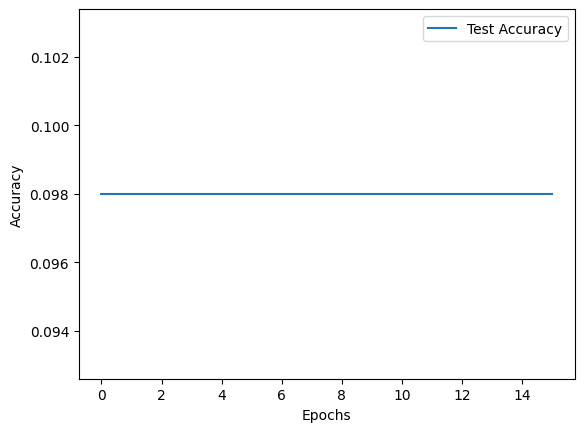

In [ ]:
plt.plot(test_accuracies, label="Test Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [ ]:
# Device 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# 전처리
transform = transforms.Compose([
    transforms.ToTensor(),           # PyTorch 텐서 변환
    transforms.Normalize((0.5,), (0.5,))  # 정규화 (-1 ~ 1)
])

In [ ]:
# MNIST 데이터셋 로드
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=100, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=100, shuffle=False)

In [ ]:
# 신경망 모델 클래스 정의
class TwoLayerNet(nn.Module):
    def __init__(self):
        super(TwoLayerNet, self).__init__()
        self.fc1 = nn.Linear(28*28, 50)  # 입력층 → 은닉층 (50 뉴런)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(50, 10)     # 은닉층 → 출력층 (10 뉴런)

    def forward(self, x):
        x = x.view(-1, 28*28)  # 2D 이미지 -> 1D 벡터 변환
        x = self.relu(self.fc1(x))
        x = self.fc2(x)  # Softmax는 CrossEntropyLoss에서 자동 적용됨
        return x

In [ ]:
# 모델, 손실함수, 최적화 함수 생성
model = TwoLayerNet().to(device)
criterion = nn.CrossEntropyLoss() #손실함수: 교차 엔트로피 함수
optimizer = optim.SGD(model.parameters(), lr=0.1)  # 경사하강법

In [ ]:
# 학습
# 5. 모델 학습
num_epochs = 16
train_losses, test_accuracies = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_losses.append(running_loss / len(train_loader))

    # 테스트 정확도 계산
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    test_acc = correct / total
    test_accuracies.append(test_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {train_losses[-1]:.4f}, Test Accuracy: {test_acc:.4f}")

Epoch [1/16], Loss: 0.4828, Test Accuracy: 0.9165
Epoch [2/16], Loss: 0.2417, Test Accuracy: 0.9420
Epoch [3/16], Loss: 0.1882, Test Accuracy: 0.9480
Epoch [4/16], Loss: 0.1566, Test Accuracy: 0.9537
Epoch [5/16], Loss: 0.1358, Test Accuracy: 0.9613
Epoch [6/16], Loss: 0.1218, Test Accuracy: 0.9593
Epoch [7/16], Loss: 0.1119, Test Accuracy: 0.9638
Epoch [8/16], Loss: 0.1034, Test Accuracy: 0.9654
Epoch [9/16], Loss: 0.0950, Test Accuracy: 0.9659
Epoch [10/16], Loss: 0.0895, Test Accuracy: 0.9690
Epoch [11/16], Loss: 0.0852, Test Accuracy: 0.9683
Epoch [12/16], Loss: 0.0809, Test Accuracy: 0.9665
Epoch [13/16], Loss: 0.0776, Test Accuracy: 0.9679
Epoch [14/16], Loss: 0.0728, Test Accuracy: 0.9704
Epoch [15/16], Loss: 0.0695, Test Accuracy: 0.9721
Epoch [16/16], Loss: 0.0681, Test Accuracy: 0.9696


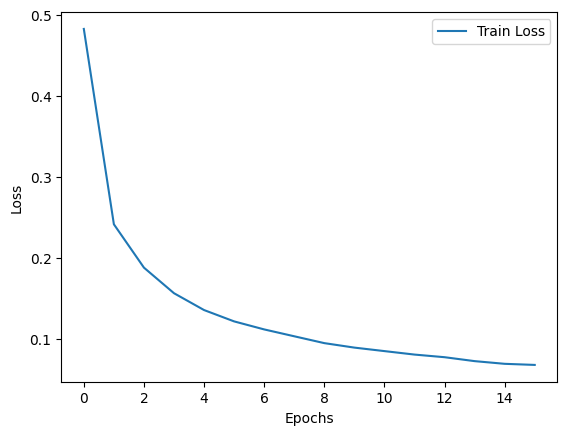

In [ ]:
# Loss 그래프 시각화, Loss 그래프는 우하향
plt.plot(train_losses, label="Train Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

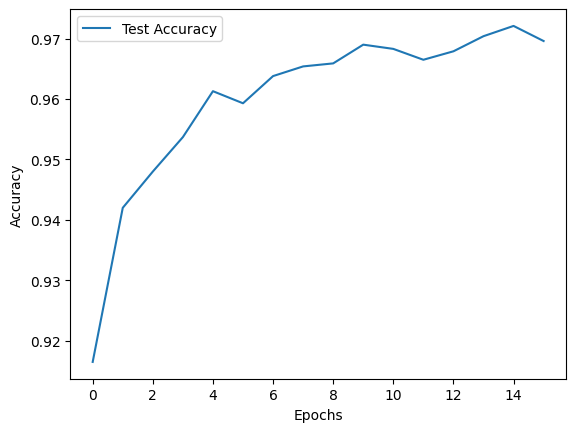

In [ ]:
# Accuracy 그래프는 우상향
plt.plot(test_accuracies, label="Test Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from datetime import datetime

In [ ]:
# Device 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# 파라메터 설정
learning_rate = 0.001
batch = 32
epochs = 15

image_size = 32
nb_class = 10

In [ ]:
# MNIST 데이셋 로드
# transforms 정의하기
transforms = transforms.Compose([transforms.Resize((image_size, image_size)),
                                 transforms.ToTensor()])

# data set 다운받고 생성하기
train_dataset = datasets.MNIST(root='./data',
                               train=True,
                               transform=transforms,
                               download=True)

valid_dataset = datasets.MNIST(root='./data',
                               train=False,
                               transform=transforms)

# data loader 정의하기
train_loader = DataLoader(dataset=train_dataset,
                          batch_size=batch,
                          shuffle=True)

valid_loader = DataLoader(dataset=valid_dataset,
                          batch_size=batch,
                          shuffle=False)

In [ ]:
# 신경망 모델 클래스 정의
class LeNet5(nn.Module):
    def __init__(self, n_classes):
        super(LeNet5, self).__init__()

        self.feature_extractor = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, stride=1),
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2),
            nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1),
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2),
            nn.Conv2d(in_channels=16, out_channels=120, kernel_size=5, stride=1),
            nn.Tanh()
        )
        self.classifier = nn.Sequential(
            nn.Linear(in_features=120, out_features=84),
            nn.Tanh(),
            nn.Linear(in_features=84, out_features=n_classes),
        )

    def forward(self, x):
        x = self.feature_extractor(x)
        x = torch.flatten(x, 1)
        logits = self.classifier(x)
        probs = F.softmax(logits, dim=1)
        return logits, probs

In [ ]:
# 예측 정확도 측정 함수
def get_accuracy(model, data_loader, device):
    correct_pred = 0
    n = 0

    with torch.no_grad():
        model.eval()
        for X, y_true in data_loader:

            X = X.to(device)
            y_true = y_true.to(device)

            _, y_prob = model(X)
            _, predicted_labels = torch.max(y_prob, 1)

            n += y_true.size(0)
            correct_pred += (predicted_labels == y_true).sum()

    return correct_pred.float() / n

In [ ]:
# Loss 시각화 함수
def plot_losses(train_losses, valid_losses):
    train_losses = np.array(train_losses)
    valid_losses = np.array(valid_losses)

    fig, ax = plt.subplots(figsize = (8, 4.5))

    ax.plot(train_losses, color='blue', label='Training loss')
    ax.plot(valid_losses, color='red', label='Validation loss')
    ax.set(title="Loss over epochs",
            xlabel='Epoch',
            ylabel='Loss')
    ax.legend()
    fig.show()

    # plot style을 기본값으로 설정
    plt.style.use('default')

In [ ]:
# Train 함수
def train(train_loader, model, criterion, optimizer, device):
    model.train()
    running_loss = 0

    for X, y_true in train_loader:

        optimizer.zero_grad()

        X = X.to(device)
        y_true = y_true.to(device)

        # 순전파
        y_hat, _ = model(X)
        loss = criterion(y_hat, y_true)
        running_loss += loss.item() * X.size(0)

        # 역전파
        loss.backward()
        optimizer.step()

    epoch_loss = running_loss / len(train_loader.dataset)
    return model, optimizer, epoch_loss

In [ ]:
# Validation 함수
def validate(valid_loader, model, criterion, device):
    model.eval()
    running_loss = 0

    for X, y_true in valid_loader:

        X = X.to(device)
        y_true = y_true.to(device)

        # 순전파와 손실 기록하기
        y_hat, _ = model(X)
        loss = criterion(y_hat, y_true)
        running_loss += loss.item() * X.size(0)

    epoch_loss = running_loss / len(valid_loader.dataset)

    return model, epoch_loss

In [ ]:
# 반복 학습 함수
def training_loop(model, criterion, optimizer, train_loader, valid_loader, epochs, device, print_every=1):
    # metrics를 저장하기 위한 객체 설정
    best_loss = 1e10
    train_losses = []
    valid_losses = []

    # model 학습하기
    for epoch in range(0, epochs):

        # training
        model, optimizer, train_loss = train(train_loader, model, criterion, optimizer, device)
        train_losses.append(train_loss)

        # validation
        with torch.no_grad():
            model, valid_loss = validate(valid_loader, model, criterion, device)
            valid_losses.append(valid_loss)

        if epoch % print_every == (print_every - 1):

            train_acc = get_accuracy(model, train_loader, device=device)
            valid_acc = get_accuracy(model, valid_loader, device=device)

            print(f'{datetime.now().time().replace(microsecond=0)} --- '
                  f'Epoch: {epoch}\t'
                  f'Train loss: {train_loss:.4f}\t'
                  f'Valid loss: {valid_loss:.4f}\t'
                  f'Train accuracy: {100 * train_acc:.2f}\t'
                  f'Valid accuracy: {100 * valid_acc:.2f}')

    plot_losses(train_losses, valid_losses)

    return model, optimizer, (train_losses, valid_losses)

11:36:16 --- Epoch: 0	Train loss: 0.2432	Valid loss: 0.1001	Train accuracy: 97.21	Valid accuracy: 97.02
11:36:44 --- Epoch: 1	Train loss: 0.0857	Valid loss: 0.0741	Train accuracy: 98.08	Valid accuracy: 97.68
11:37:12 --- Epoch: 2	Train loss: 0.0607	Valid loss: 0.0614	Train accuracy: 98.58	Valid accuracy: 98.07
11:37:40 --- Epoch: 3	Train loss: 0.0454	Valid loss: 0.0480	Train accuracy: 98.98	Valid accuracy: 98.42
11:38:08 --- Epoch: 4	Train loss: 0.0401	Valid loss: 0.0452	Train accuracy: 99.20	Valid accuracy: 98.62
11:38:36 --- Epoch: 5	Train loss: 0.0325	Valid loss: 0.0493	Train accuracy: 99.26	Valid accuracy: 98.48
11:39:03 --- Epoch: 6	Train loss: 0.0282	Valid loss: 0.0538	Train accuracy: 99.19	Valid accuracy: 98.36
11:39:31 --- Epoch: 7	Train loss: 0.0228	Valid loss: 0.0461	Train accuracy: 99.53	Valid accuracy: 98.51
11:39:59 --- Epoch: 8	Train loss: 0.0216	Valid loss: 0.0459	Train accuracy: 99.38	Valid accuracy: 98.56
11:40:27 --- Epoch: 9	Train loss: 0.0192	Valid loss: 0.0494	Trai

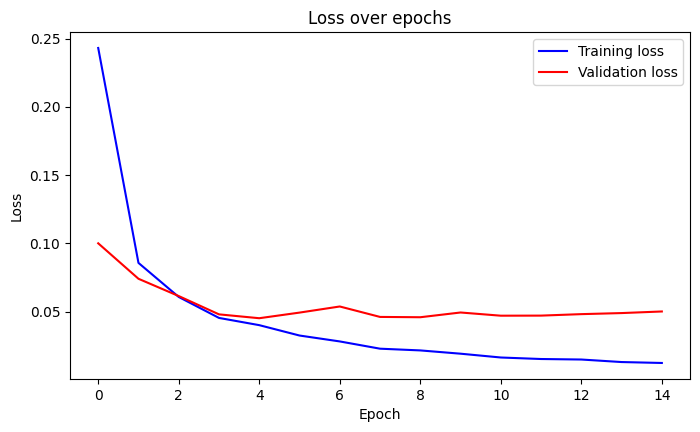

In [ ]:
#RANDOM_SEED = 42
#torch.manual_seed(RANDOM_SEED)

model = LeNet5(nb_class).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()


model, optimizer, _ = training_loop(model, criterion, optimizer, train_loader,
                                    valid_loader, epochs, device)

In [1]:
#토큰나이저 설치
!pip install sentencepiece
#데이터 직렬화 util 설치
!pip install protobuf
#Hugging face 의 trasnformer 설치
!pip install transformers

In [2]:
# 예제 이미지 다운로드
!rm -rf ocr_test_image
!mkdir ocr_test_image
#!cd ocr_test_image && wget https://fki.tic.heia-fr.ch/static/img/a01-122-02.jpg
!cd ocr_test_image && wget https://github.com/jskimn/aiservice_lesson/raw/main/001_ocr/a01-122-02.jpg
!cd ocr_test_image && wget https://github.com/jskimn/aiservice_lesson/raw/main/001_ocr/Hello.jpg
!cd ocr_test_image && wget https://github.com/jskimn/aiservice_lesson/raw/main/001_ocr/test_01.png
!cd ocr_test_image && wget https://github.com/jskimn/aiservice_lesson/raw/main/001_ocr/test_02.png

--2025-04-08 10:54:56--  https://github.com/jskimn/aiservice_lesson/raw/main/001_ocr/a01-122-02.jpg
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/jskimn/aiservice_lesson/main/001_ocr/a01-122-02.jpg [following]
--2025-04-08 10:54:56--  https://raw.githubusercontent.com/jskimn/aiservice_lesson/main/001_ocr/a01-122-02.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 13376 (13K) [image/jpeg]
Saving to: ‘a01-122-02.jpg’

a01-122-02.jpg      100%[===================>]  13.06K  --.-KB/s    in 0.001s  

2025-04-08 10:54:57 (23.8 MB/s) - ‘a01-122-02.jpg’ saved [13376/13376]

--2025-04-08 10:54:57-- 

In [3]:
# 패키지 불러오기
from PIL import Image
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
import matplotlib.pyplot as plt

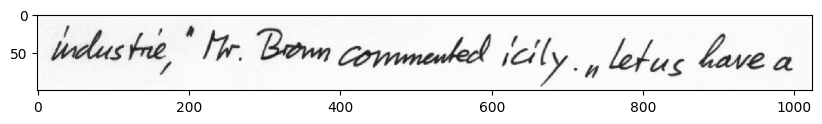

In [4]:
# Load image, 테스트 이미지 불러오기
image = Image.open("./ocr_test_image/a01-122-02.jpg").convert("RGB")

plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.axis("on")
plt.show()

In [5]:
# 모델 로딩
print("[INFO] Load pretrained TrOCRProcessor")
processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten")
print("[INFO] Load pretrained VisionEncoderDecoderModel")
model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-handwritten")

[INFO] Load pretrained TrOCRProcessor


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


tokenizer_config.json:   0%|          | 0.00/1.12k [00:00<?, ?B/s]

...

[INFO] Load pretrained VisionEncoderDecoderModel


config.json:   0%|          | 0.00/4.17k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Config of the encoder: <class 'transformers.models.vit.modeling_vit.ViTModel'> is overwritten by shared encoder config: ViTConfig {
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 384,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "pooler_act": "tanh",
  "pooler_output_size": 768,
  "qkv_bias": false,
  "torch_dtype": "float32",
  "transformers_version": "4.50.3"
}

Config of the decoder: <class 'transformers.models.trocr.modeling_trocr.TrOCRForCausalLM'> is overwritten by shared decoder config: TrOCRConfig {
  "activation_dropout": 0.0,
  "activation_function": "gelu",
  "add_cross_attention": true,
  "attention_dropout": 0.0,
  "bos_token_id": 0,
  "classifier_dropout": 0.0,
  "cross_attention_hidden_size": 768,
  "d_mod

generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [8]:
# 추론하기
# Preprocess
pixel_values = processor(images=image, return_tensors="pt").pixel_values
# Inference
token_ids = model.generate(pixel_values)
# Postprocess
text_from_image = processor.batch_decode(token_ids, skip_special_tokens=True)[0]

In [7]:
text_from_image

'industry , " Mr. Brown commented icily . " Let us have a'

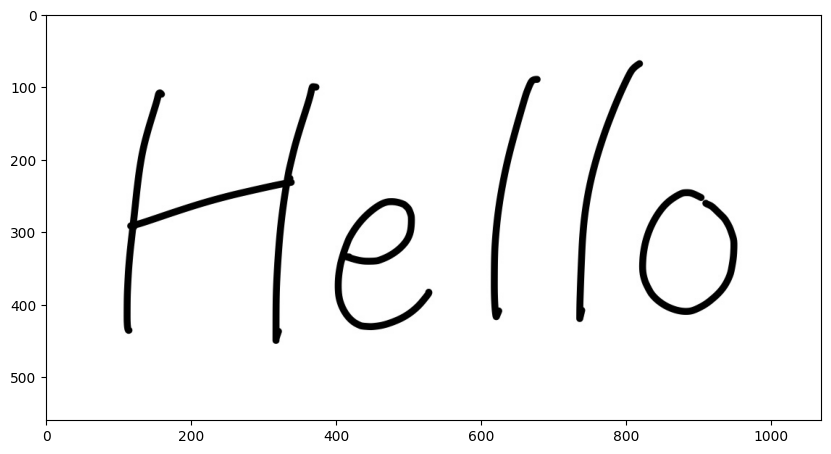

In [9]:
# Load image
image = Image.open("./ocr_test_image/Hello.jpg").convert("RGB")

plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.axis("on")
plt.show()

In [10]:
# 추론하기
# Preprocess
pixel_values = processor(images=image, return_tensors="pt").pixel_values
# Inference
token_ids = model.generate(pixel_values)
# Postprocess
text_from_image = processor.batch_decode(token_ids, skip_special_tokens=True)[0]

In [11]:
text_from_image

'Hello'

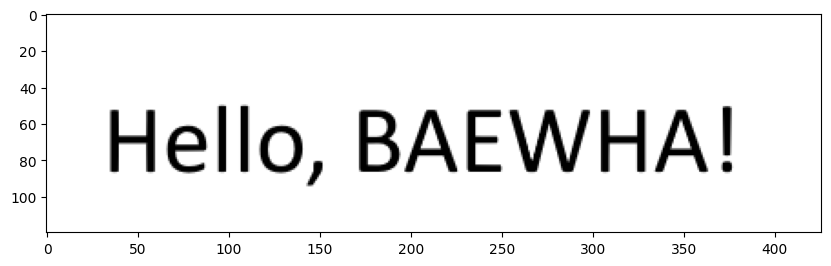

In [13]:
# Load image
image = Image.open("./ocr_test_image/test_01.png").convert("RGB")

plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.axis("on")
plt.show()

In [14]:
# 추론하기
# Preprocess
pixel_values = processor(images=image, return_tensors="pt").pixel_values
# Inference
token_ids = model.generate(pixel_values)
# Postprocess
text_from_image = processor.batch_decode(token_ids, skip_special_tokens=True)[0]

In [15]:
text_from_image

'Hello , BAEWHARI'

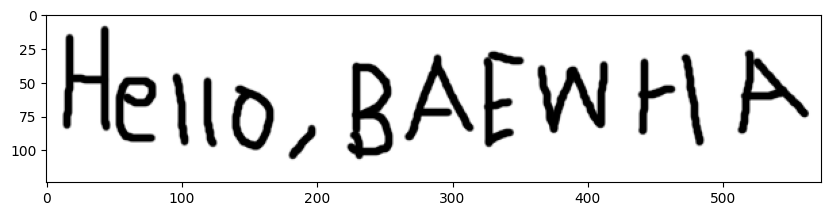

In [16]:
# Load image
image = Image.open("./ocr_test_image/test_02.png").convert("RGB")

plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.axis("on")
plt.show()

In [17]:
# 추론하기
# Preprocess
pixel_values = processor(images=image, return_tensors="pt").pixel_values
# Inference
token_ids = model.generate(pixel_values)
# Postprocess
text_from_image = processor.batch_decode(token_ids, skip_special_tokens=True)[0]

In [18]:
text_from_image

'HE110 , BAEW H.A.'

In [ ]:
# 22일까지 004_AI서비스_OCR_v1.1 12p 참고해서 과제
# 한글 ORC 모델 실행해보기, * 입력 이미지: 본인 이름
# 교수님 추천 모델: trocr-small-korea 동작하는지는 잘 모르신다고...

In [19]:
# Hugging Face Transformers 라이브러리 설치
!pip install transformers
# Hugging Face Datasets 라이브러리 설치
!pip install datasets
# OCR을 위한 PIL 설치
!pip install pillow
# Tesseract OCR 설치
!apt-get install tesseract-ocr
# 한글을 인식할 수 있도록 Tesseract에 한글 패키지 추가
!apt-get install -y tesseract-ocr-kor

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 16.0 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system 

In [37]:
!pip install transformers
!pip install datasets
!pip install pillow
!apt-get install tesseract-ocr
!apt-get install -y tesseract-ocr-kor

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 30 not upgraded.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr-kor is already the newest version (1:4.00~git30-7274cfa-1.1).
0 upgraded, 0 newly installed, 0 to remove and 30 not upgraded.


In [24]:
!pip install pytesseract

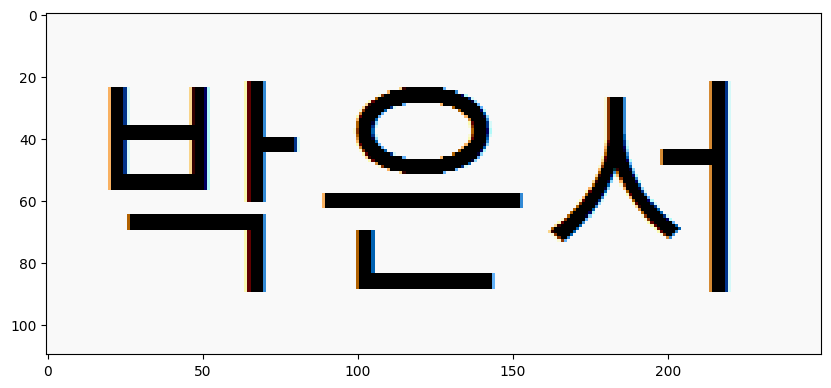

In [27]:
image = Image.open("./my_name_image.png").convert("RGB")

plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.axis("on")
plt.show()

In [38]:
custom_config = r'--oem 1 --psm 6'

text = pytesseract.image_to_string(img, lang='kor', config=custom_config)

print("추출된 텍스트:", text)

추출된 텍스트: 박은서



In [36]:
# PSM (Page Segmentation Mode)과 OEM (OCR Engine Mode)을 설정
custom_config = r'--oem 1 --psm 6'

# OCR 실행
text = pytesseract.image_to_string(img, lang='kor', config=custom_config)

# 결과 출력
print("추출된 텍스트:", text)

추출된 텍스트: 박은서



In [28]:
from PIL import Image
import pytesseract

# Tesseract OCR 경로 설정
pytesseract.pytesseract.tesseract_cmd = '/usr/bin/tesseract'

# 이미지 파일을 로드 (본인의 이름 이미지 사용)
img = Image.open('my_name_image.png')

# OCR을 이용해 텍스트 추출
text = pytesseract.image_to_string(img, lang='kor')  # 한글 언어 설정

print("추출된 텍스트:", text)

추출된 텍스트: 더
이|



In [32]:
''' from huggingface_hub import login

# Hugging Face에서 발급받은 토큰을 사용하여 로그인
login(token="your_hugging_face_token") '''

HTTPError: Invalid user token.

In [29]:
''' from transformers import AutoModelForImageClassification, AutoProcessor
import torch

# 모델과 프로세서 로드
model_name = "Ocr-model-name"  # 해당 모델 이름을 넣으세요
processor = AutoProcessor.from_pretrained(model_name)
model = AutoModelForImageClassification.from_pretrained(model_name)

# 이미지 준비
img = Image.open('my_name_image.png')

# 텍스트 인식
inputs = processor(images=img, return_tensors="pt")
outputs = model(**inputs)
logits = outputs.logits
predicted_class_idx = logits.argmax(-1).item()

# 결과 출력
print(f"예측된 텍스트: {predicted_class_idx}") '''

OSError: Ocr-model-name is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `huggingface-cli login` or by passing `token=<your_token>`

In [30]:
''' from transformers import AutoProcessor, AutoModelForImageClassification
import torch
from PIL import Image

# 모델과 프로세서 로드
model_name = "tesseract-ocr-kor"  # 실제 모델 이름으로 교체
processor = AutoProcessor.from_pretrained(model_name)
model = AutoModelForImageClassification.from_pretrained(model_name)

# 이미지 준비 (여기서는 이름을 넣은 이미지를 사용)
img = Image.open('my_name_image.png')

# 텍스트 인식
inputs = processor(images=img, return_tensors="pt")
outputs = model(**inputs)
logits = outputs.logits
predicted_class_idx = logits.argmax(-1).item()

# 결과 출력
print(f"예측된 텍스트: {predicted_class_idx}") '''


OSError: tesseract-ocr-kor is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `huggingface-cli login` or by passing `token=<your_token>`

In [33]:
''' from transformers import AutoProcessor, AutoModelForImageClassification
import torch
from PIL import Image

# 모델과 프로세서 로드
model_name = "mrm8488/bertine-ocr"  # 실제 모델 이름
processor = AutoProcessor.from_pretrained(model_name)
model = AutoModelForImageClassification.from_pretrained(model_name)

# 이미지 준비
img = Image.open('my_name_image.png')

# 텍스트 인식
inputs = processor(images=img, return_tensors="pt")
outputs = model(**inputs)
logits = outputs.logits
predicted_class_idx = logits.argmax(-1).item()

# 결과 출력
print(f"예측된 텍스트: {predicted_class_idx}") '''


OSError: mrm8488/bertine-ocr is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `huggingface-cli login` or by passing `token=<your_token>`

In [35]:
from PIL import Image
import pytesseract

# 한글 언어 설정 (tesseract-ocr-kor 설치 필요)
pytesseract.pytesseract.tesseract_cmd = '/usr/bin/tesseract'

# 이미지 로드
img = Image.open('my_name_image.png')

# OCR을 이용해 텍스트 추출
text = pytesseract.image_to_string(img, lang='kor')  # 한글 언어 사용

# 결과 출력
print("추출된 텍스트:", text)

추출된 텍스트: 2

<
이]

